# E2E Deep Learning — Mass Regression
## GSoC 2026 Evaluation Task 2f + 2g
**Author:** Vineet Kumar  
**Date:** March 2026  
**Organization:** ML4Sci / E2E Project

## Summary
End-to-end CNN regression model for particle mass estimation 
from CMS calorimeter images. Trained on 150K events from the 
`top_gun_opendata` dataset using an incremental chunk-based 
training pipeline across 2x T4 GPUs. Three training experiments 
were conducted - see detailed results below.

**Best Model:** 91 GeV RMSE | 30.69% Relative Error (150K events)

## Task 2f — Mass Regression Results

### Experiment Comparison
| Attempt | Dataset | Normalization | RMSE | Rel Error |
|---------|---------|---------------|------|-----------|
| 1 | 1K events | None | 114 GeV | 43% |
| **2 (best)** | **150K events** | **None** | **91 GeV** | **30%** |
| 3 | 600K events | Clip+norm | 112 GeV | 40% |

### Best Model: *Attempt 2*
### Approach
- 4-channel CNN (Track pT, DZ, D0, ECAL) trained on 125×125 calorimeter images
- Incremental training across 150,327 events in chunks of 3,000
- Multi-GPU training (2x T4) with DataParallel
- Adam optimizer, MSE loss, ReduceLROnPlateau scheduler

### Results
| Metric | Test Set (File 0) | Test Set (File 3) |
|--------|------------------|------------------|
| MAE | 72.38 GeV | 89.59 GeV |
| RMSE | 91.20 GeV | 114.85 GeV |
| Mean Relative Error | 30.69% | 32.52% |
| Mass range | 86.3 - 497.9 GeV | 85.8 - 499.3 GeV |

**Note:** Small performance difference across test sets (30.69% vs 
32.52%) indicates reasonable generalization across different data files.

### Observations
- Attempt 2, Anomalous loss spikes observed in chunks 6, 23, 35, 47. 
  suggesting outlier events worth investigating in preprocessing
- Attempt 2, LR scheduler did not trigger, constant lr=1e-3 throughout
  (identified as scheduler placement bug, fixed in Attempt 3)
- Attempt 3 (600K, normalized) underperformed due to LR 
  collapsing to ~1e-8 by chunk 22, model stopped learning
  for remaining 450K events

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from sklearn.model_selection import train_test_split
from torch.cuda.amp import autocast, GradScaler
import time
import gc



DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("DEVICE:", DEVICE)

print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0))
print(torch.cuda.get_device_name(1))

DEVICE: cuda
2
Tesla T4
Tesla T4


In [2]:
# Verify all files accessible
import os

files = [
    '/kaggle/input/datasets/vineet0san/cms-e2e-jets/data00.parquet',
    '/kaggle/input/datasets/vineet0san/cms-e2e-jets/data01.parquet',
    '/kaggle/input/datasets/vineet0san/cms-e2e-jets/data02.parquet',
    '/kaggle/input/datasets/vineet0san/cms-e2e-jets/data03.parquet'
]

CHUNK_SIZE = 3000
total_events = 0

for f in files:
    pf = pq.ParquetFile(f)
    n = pf.metadata.num_rows
    total_events += n
    print(f"{f.split('/')[-1]}: {n:,} events | {n//CHUNK_SIZE} chunks")

print(f"\nTotal events: {total_events:,}")
print(f"Total chunks: {total_events//CHUNK_SIZE}")
print(f"Chunk size: {CHUNK_SIZE}")

data00.parquet: 150,327 events | 50 chunks
data01.parquet: 150,165 events | 50 chunks
data02.parquet: 150,451 events | 50 chunks
data03.parquet: 150,448 events | 50 chunks

Total events: 601,391
Total chunks: 200
Chunk size: 3000


In [3]:
CLIP_PERCENTILE = 99

def build_images(df_chunk):
    images, targets = [], []
    for _, row in df_chunk.iterrows():
        xjet = row['X_jet']
        channels = []
        for ch in range(4):
            img = np.stack([xjet[ch][r] for r in range(125)]).astype(np.float32)
            p99 = np.percentile(img, CLIP_PERCENTILE)
            if p99 > 0:
                img = np.clip(img, 0, p99) / p99
            channels.append(img)
        image = np.stack(channels)
        images.append(image)
        targets.append(np.float32(row['m']))
    print(f"  Built {len(images)} images")
    return np.stack(images), np.array(targets)

In [4]:
# Model Class
class MassRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(4, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # 62x62
            
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # 31x31
            
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # 15x15
            
            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(4)
        )
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*4*4, 512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 128),     nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.regressor(self.features(x)).squeeze(1)


In [5]:
model = MassRegressor().to(DEVICE)

if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=5, factor=0.5
)
criterion = nn.MSELoss()
best_val_loss = float('inf')
EPOCHS_PER_CHUNK = 3

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print("Training from scratch on normalized data")

Using 2 GPUs
Model parameters: 2,552,161
Training from scratch on normalized data


In [7]:

files = [
    '/kaggle/input/datasets/vineet0san/cms-e2e-jets/data00.parquet',
    '/kaggle/input/datasets/vineet0san/cms-e2e-jets/data01.parquet',
    '/kaggle/input/datasets/vineet0san/cms-e2e-jets/data02.parquet',
    '/kaggle/input/datasets/vineet0san/cms-e2e-jets/data03.parquet'
]

CHUNK_SIZE = 3000

for file_idx, filepath in enumerate(files):
    print(f"\n{'#'*55}")
    print(f"FILE {file_idx+1}/{len(files)}: {filepath.split('/')[-1]}")
    print(f"{'#'*55}")

    pf = pq.ParquetFile(filepath)
    total_chunks = pf.metadata.num_rows // CHUNK_SIZE

    for chunk_idx, batch in enumerate(pf.iter_batches(batch_size=CHUNK_SIZE)):

        # last chunk of last file reserved for final test
        if file_idx == len(files)-1 and chunk_idx == total_chunks-1:
            print("Reached last chunk (>_<) !! reserved for final test")
            break

        print(f"\n{'='*55}")
        print(f"File {file_idx+1} | Chunk {chunk_idx+1}/{total_chunks} | "
              f"Events {chunk_idx*CHUNK_SIZE}-{(chunk_idx+1)*CHUNK_SIZE}")
        print(f"{'='*55}")

        df_chunk = batch.to_pandas()
        X_all, y_all = build_images(df_chunk)

        X_tr, X_val, y_tr, y_val = train_test_split(
            X_all, y_all, test_size=0.2, random_state=42
        )

        train_loader = DataLoader(
            torch.utils.data.TensorDataset(
                torch.tensor(X_tr), torch.tensor(y_tr)
            ), batch_size=64, shuffle=True
        )
        val_loader = DataLoader(
            torch.utils.data.TensorDataset(
                torch.tensor(X_val), torch.tensor(y_val)
            ), batch_size=64, shuffle=False
        )

        for epoch in range(EPOCHS_PER_CHUNK):
            epoch_start = time.time()

            model.train()
            train_loss = 0
            for X, y in train_loader:
                X, y = X.to(DEVICE), y.to(DEVICE)
                optimizer.zero_grad()
                loss = criterion(model(X), y)
                loss.backward()
                optimizer.step()
                train_loss += loss.item()

            model.eval()
            val_loss = 0
            with torch.no_grad():
                for X, y in val_loader:
                    X, y = X.to(DEVICE), y.to(DEVICE)
                    val_loss += criterion(model(X), y).item()

            train_loss /= len(train_loader)
            val_loss   /= len(val_loader)
            scheduler.step(val_loss)
            epoch_time = time.time() - epoch_start
            current_lr = optimizer.param_groups[0]['lr']

            print(f"  Epoch {epoch+1}/{EPOCHS_PER_CHUNK} | "
                  f"Train MSE: {train_loss:.2f} | "
                  f"Val MSE: {val_loss:.2f} | "
                  f"LR: {current_lr:.2e} | "
                  f"Time: {epoch_time:.1f}s")

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save(model.module.state_dict(), 'best_model.pt')
                print("!!Best model saved!!")

        del X_all, y_all, X_tr, X_val, y_tr, y_val
        gc.collect()

print(f"\nTraining complete | Best Val MSE: {best_val_loss:.2f}")


#######################################################
FILE 1/4: data00.parquet
#######################################################

File 1 | Chunk 1/50 | Events 0-3000
  Built 3000 images
  Epoch 1/3 | Train MSE: 74008.55 | Val MSE: 70114.20 | LR: 1.00e-03 | Time: 2.4s
!!Best model saved!!
  Epoch 2/3 | Train MSE: 37066.90 | Val MSE: 16538.94 | LR: 1.00e-03 | Time: 1.2s
!!Best model saved!!
  Epoch 3/3 | Train MSE: 16552.50 | Val MSE: 15226.03 | LR: 1.00e-03 | Time: 1.2s
!!Best model saved!!

File 1 | Chunk 2/50 | Events 3000-6000
  Built 3000 images
  Epoch 1/3 | Train MSE: 15779.83 | Val MSE: 14777.40 | LR: 1.00e-03 | Time: 1.3s
!!Best model saved!!
  Epoch 2/3 | Train MSE: 15398.71 | Val MSE: 14787.30 | LR: 1.00e-03 | Time: 1.2s
  Epoch 3/3 | Train MSE: 15125.16 | Val MSE: 14716.48 | LR: 1.00e-03 | Time: 1.2s
!!Best model saved!!

File 1 | Chunk 3/50 | Events 6000-9000
  Built 3000 images
  Epoch 1/3 | Train MSE: 14857.65 | Val MSE: 14751.43 | LR: 1.00e-03 | Time: 1.3s
  Epoc

In [8]:
# Load last chunk of last file (data03.parquet)
pf_test = pq.ParquetFile('/kaggle/input/datasets/vineet0san/cms-e2e-jets/data03.parquet')
total_chunks_test = pf_test.metadata.num_rows // CHUNK_SIZE

for i, batch in enumerate(pf_test.iter_batches(batch_size=CHUNK_SIZE)):
    if i == total_chunks_test:
        df_test = batch.to_pandas()
        break

X_test, y_test = build_images(df_test)
print(f"Test set: {len(X_test)} events")

best_model = MassRegressor().to(DEVICE)
best_model.load_state_dict(torch.load('best_model.pt'))
best_model.eval()

test_loader = DataLoader(
    torch.utils.data.TensorDataset(
        torch.tensor(X_test), torch.tensor(y_test)
    ), batch_size=64, shuffle=False
)

preds, targets = [], []
with torch.no_grad():
    for X, y in test_loader:
        X = X.to(DEVICE)
        preds.extend(best_model(X).cpu().numpy())
        targets.extend(y.numpy())

preds   = np.array(preds)
targets = np.array(targets)

mae  = np.mean(np.abs(preds - targets))
rmse = np.sqrt(np.mean((preds - targets)**2))
rel  = np.mean(np.abs(preds - targets) / targets) * 100

print(f"\nFinal Test Results")
print(f"{'='*40}")
print(f"MAE:                 {mae:.2f} GeV")
print(f"RMSE:                {rmse:.2f} GeV")
print(f"Mean Relative Error: {rel:.2f}%")
print(f"Target range:        {targets.min():.1f} - {targets.max():.1f} GeV")

  Built 448 images
Test set: 448 events

Final Test Results
MAE:                 93.26 GeV
RMSE:                111.83 GeV
Mean Relative Error: 40.51%
Target range:        85.8 - 499.3 GeV


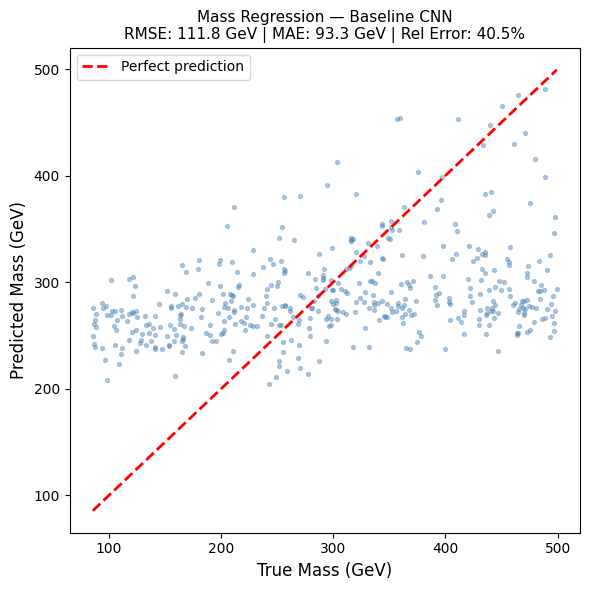

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(targets, preds, alpha=0.4, s=8, color='steelblue')
plt.plot([targets.min(), targets.max()],
         [targets.min(), targets.max()],
         'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('True Mass (GeV)', fontsize=12)
plt.ylabel('Predicted Mass (GeV)', fontsize=12)
plt.title(f'Mass Regression — Baseline CNN\nRMSE: {rmse:.1f} GeV | MAE: {mae:.1f} GeV | Rel Error: {rel:.1f}%', fontsize=11)
plt.legend()
plt.tight_layout()
plt.savefig('baseline_regression.png', dpi=150)
plt.show()

In [11]:
best_model = MassRegressor().to(DEVICE)
best_model.load_state_dict(torch.load('/kaggle/input/datasets/vineet0san/best-model-over-150kfile-0-nonorm/best_model_150K.pt'))
best_model.eval()

print("Model loaded successfully")
print(f"Parameters: {sum(p.numel() for p in best_model.parameters()):,}")

Model loaded successfully
Parameters: 2,552,161


In [12]:
test_loader = DataLoader(
    torch.utils.data.TensorDataset(
        torch.tensor(X_test), torch.tensor(y_test)
    ), batch_size=64, shuffle=False
)

preds, targets = [], []
with torch.no_grad():
    for X, y in test_loader:
        X = X.to(DEVICE)
        preds.extend(best_model(X).cpu().numpy())
        targets.extend(y.numpy())

preds   = np.array(preds)
targets = np.array(targets)

mae  = np.mean(np.abs(preds - targets))
rmse = np.sqrt(np.mean((preds - targets)**2))
rel  = np.mean(np.abs(preds - targets) / targets) * 100

print(f"MAE:                 {mae:.2f} GeV")
print(f"RMSE:                {rmse:.2f} GeV")
print(f"Mean Relative Error: {rel:.2f}%")

MAE:                 89.59 GeV
RMSE:                114.85 GeV
Mean Relative Error: 32.52%


In [16]:
!pip install onnxscript -q
!pip install onnxruntime -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 21.2 MB/s eta 0:00:0000:0100:01


In [17]:
import torch.onnx

best_model.eval()
best_model = best_model.to('cpu')

# Dummy input := batch=1, 4 channels, 125x125
dummy_input = torch.randn(1, 4, 125, 125)


torch.onnx.export(
    best_model,
    dummy_input,
    'mass_regressor.onnx',
    export_params=True,
    opset_version=18,
    input_names=['X_jet'],
    output_names=['mass'],
    dynamic_axes={
        'X_jet': {0: 'batch_size'},
        'mass':  {0: 'batch_size'}
    }
)

print("ONNX export successful")

# Verify
import onnxruntime as ort
sess = ort.InferenceSession('mass_regressor.onnx')
dummy_np = np.random.randn(1, 4, 125, 125).astype(np.float32)
out = sess.run(['mass'], {'X_jet': dummy_np})
print(f"ONNX inference test passed")
print(f"Output shape: {out[0].shape}")
print(f"Sample output: {out[0]}")

/tmp/ipykernel_55/4248624643.py:10: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


[torch.onnx] Obtain model graph for `MassRegressor([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MassRegressor([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
ONNX export successful
ONNX inference test passed
Output shape: (1,)
Sample output: [1730.8209]
